In [2]:
# Regular Python library imports 
import xarray as xr 
import numpy as np
import pandas as pd
import pyproj
import scipy.interpolate
import matplotlib.pyplot as plt
import glob
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# Helper functions for reading the data from the bucket and plotting
from utils.read_data_utils import read_IS2SITMOGR4, read_book_data
from utils.plotting_utils import static_winter_comparison_lineplot, staticArcticMaps, interactiveArcticMaps, compute_gridcell_winter_means, interactive_winter_comparison_lineplot # Plotting utils 
from utils.extra_funcs import read_IS2SITMOGR4S, regrid_ubris_to_is2, get_cs2is2_snow, apply_interpolation_time
# Plotting dependencies
#%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 

# Get the current working directory
current_directory = os.getcwd()

In [3]:
# Load the winter IS-2 thickness data from zarr/s3
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='zarr-s3', persist=True) 
#IS2SITMOGR4_v3

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr


In [4]:
# Get some IS2 map projection/domain info needed for later functions
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj("+init=" + out_proj)

xIS2 = IS2SITMOGR4_v3.x.values
yIS2 = IS2SITMOGR4_v3.y.values
xptsIS2, yptsIS2 = np.meshgrid(xIS2, yIS2)
out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

In [5]:
# interpolate variables unique to the winter dataset (the sm data are already interpolated in summer and summer has no modified warren data)

IS2SITMOGR4_v3 = apply_interpolation_time(IS2SITMOGR4_v3, xptsIS2, yptsIS2, ['snow_depth_sm', 'ice_thickness_sm', 'snow_depth_mw99', 'ice_thickness_mw99'])

Creating/forcing new variable snow_depth_sm_int
snow_depth_sm 0
Interpolated.
snow_depth_sm 1
Interpolated.
snow_depth_sm 2
Interpolated.
snow_depth_sm 3
Interpolated.
snow_depth_sm 4
Interpolated.
snow_depth_sm 5
Interpolated.
snow_depth_sm 6
Interpolated.
snow_depth_sm 7
Interpolated.
snow_depth_sm 8
Interpolated.
snow_depth_sm 9
Interpolated.
snow_depth_sm 10
Interpolated.
snow_depth_sm 11
Interpolated.
snow_depth_sm 12
Interpolated.
snow_depth_sm 13
Interpolated.
snow_depth_sm 14
Interpolated.
snow_depth_sm 15
Interpolated.
snow_depth_sm 16
Interpolated.
snow_depth_sm 17
Interpolated.
snow_depth_sm 18
Interpolated.
snow_depth_sm 19
Interpolated.
snow_depth_sm 20
Interpolated.
snow_depth_sm 21
Interpolated.
snow_depth_sm 22
no data or issue with gridding, so skipping...
snow_depth_sm 23
no data or issue with gridding, so skipping...
snow_depth_sm 24
no data or issue with gridding, so skipping...
snow_depth_sm 25
no data or issue with gridding, so skipping...
snow_depth_sm 26
no data

In [6]:
# Read in the new summer IS-2 thickness data locally (not on s3 yet)
IS2SITMOGR4_summer_v0 = read_IS2SITMOGR4S(local_data_path="./data/IS2SITMOGR4S/")


./data/IS2SITMOGR4S/V1/*.nc


In [7]:
IS2SITMOGR4_summer_v0

<xarray.Dataset>
Dimensions:                         (time: 11, y: 448, x: 304)
Coordinates:
  * time                            (time) datetime64[ns] 2019-05-01 ... 2021...
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/33)
    crs                             (time) int32 -2147483647 ... -2147483647
    ice_thickness_sm_e5             (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_unc_freeboard     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_ice_density   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_density  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_depth    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

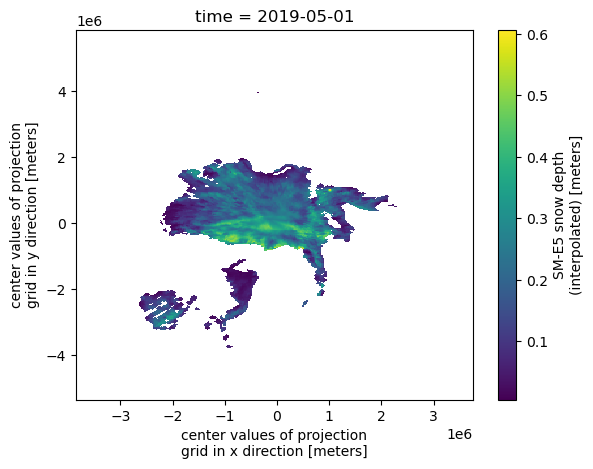

In [8]:
IS2SITMOGR4_summer_v0.snow_depth_sm_e5_int.isel(time=0).plot()

In [9]:
IS2SITMOGR4_summer_v0

<xarray.Dataset>
Dimensions:                         (time: 11, y: 448, x: 304)
Coordinates:
  * time                            (time) datetime64[ns] 2019-05-01 ... 2021...
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/33)
    crs                             (time) int32 -2147483647 ... -2147483647
    ice_thickness_sm_e5             (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_unc_freeboard     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_ice_density   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_density  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_depth    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [10]:
rename_dict = {
    'snow_depth_sm_e5': 'snow_depth_sm',
    'snow_depth_sm_e5_int': 'snow_depth_sm_int',
    'snow_density_sm_e5': 'snow_density_sm',
    'ice_thickness_sm_e5': 'ice_thickness_sm',
    'ice_thickness_sm_e5_int': 'ice_thickness_sm_int',
    'ice_thickness_sm_e5_j22': 'ice_thickness_sm_j22',
    'ice_thickness_sm_e5_j22_int': 'ice_thickness_sm_j22_int',
    # Add more if needed
}
IS2SITMOGR4_summer_v0 = IS2SITMOGR4_summer_v0.rename(rename_dict)

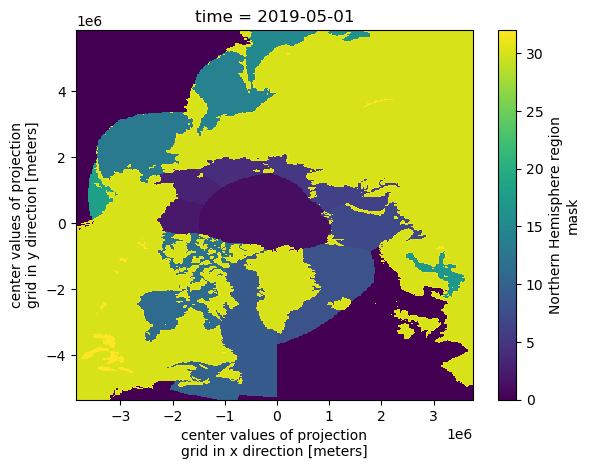

In [11]:
# Quick check it looks interpolated..!
IS2SITMOGR4_summer_v0.region_mask.isel(time=0).plot()

In [12]:
# Merge winter and summer IS-2 thickness data into one dataset
IS2SITMOGR4_allseason = IS2SITMOGR4_summer_v0.merge(IS2SITMOGR4_v3)

In [13]:
IS2SITMOGR4_allseason

<xarray.Dataset>
Dimensions:                         (time: 57, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/45)
    crs                             (time) float64 dask.array<chunksize=(57,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 dask.array<chunksize=(7, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99_int             (time, y, x) float32 nan nan nan ... nan nan
    ice_thickness_mw99_int          (time, y, x) float32 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [ ]:
# Interpoalte variables that still need it in the all-season dataset
interp_vars=[
 'snow_density',
 'snow_density_sm',
 'snow_density_sm_m2',
 'snow_density_w99',
 'snow_depth_sm_m2',
 'ice_thickness_sm_m2',
 'ice_thickness_sm_j22',
 'ice_thickness_sm_m2_j22',
 'ice_density_j22']

IS2SITMOGR4_allseason = apply_interpolation_time(IS2SITMOGR4_allseason, xptsIS2, yptsIS2, interp_vars)

Creating/forcing new variable snow_density_int
snow_density 0
Interpolated.
snow_density 1
Interpolated.
snow_density 2
Interpolated.
snow_density 3
Interpolated.
snow_density 4
Interpolated.
snow_density 5
Interpolated.
snow_density 6
no data or issue with gridding, so skipping...
snow_density 7
no data or issue with gridding, so skipping...
snow_density 8
no data or issue with gridding, so skipping...
snow_density 9
Interpolated.
snow_density 10
Interpolated.
snow_density 11
Interpolated.
snow_density 12
Interpolated.
snow_density 13
Interpolated.
snow_density 14
Interpolated.
snow_density 15
Interpolated.
snow_density 16
Interpolated.
snow_density 17
no data or issue with gridding, so skipping...
snow_density 18
no data or issue with gridding, so skipping...
snow_density 19
no data or issue with gridding, so skipping...
snow_density 20
no data or issue with gridding, so skipping...
snow_density 21
Interpolated.
snow_density 22
Interpolated.
snow_density 23
Interpolated.
snow_density

In [ ]:
IS2SITMOGR4_allseason

<xarray.Dataset>
Dimensions:                         (time: 57, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/50)
    crs                             (time) float64 dask.array<chunksize=(57,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 dask.array<chunksize=(7, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_mw99_int          (time, y, x) float32 nan nan nan ... nan nan
    snow_density_int                (time, y, x) float32 nan nan nan ... nan nan
    snow_density_sm_int             (time, y, x) float32 nan nan nan ... nan nan
    snow_density_sm_m2_int          (time, y, x) float32 nan nan nan ... nan nan
    snow_density_w99_int            (time, y, x) float32 nan nan nan ... nan nan
    ice_density_j22_int             (time, y, x) float32 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [ ]:
# Get UBRIS/UIT CS-2 data
start_date_cs2 = "Oct 2018"
end_date_cs2 = "July 2021"
# NB: MS indicates a time frequency of start of the month
date_range_cs2 = pd.date_range(start=start_date_cs2, end=end_date_cs2, freq='MS') 

# Re-grid the UBRIS/UIT CS-2 data to the IS-2 grid.
# Includes monthly resampling of the biweekly data
cs2_ubris = regrid_ubris_to_is2(mapProj, xIS2, yIS2, out_lons, out_lats, date_range_cs2,
                             dataPathCS2=current_directory+'/data/', dataset='uit_cryosat2_seaicethickness_nh_80km_v1p7.nc')

# Relabel the cs2_sea_ice_thickness_UBRIS variable to ice_thickness_cs2_ubris
cs2_ubris = cs2_ubris.rename({'cs2_sea_ice_thickness_UBRIS': 'ice_thickness_cs2_ubris'})


In [ ]:
# Get the preliminary IS-2/CS-2 winter snow depths, downlaoded from Zenodo
cs2is2_snow_regridded_da = get_cs2is2_snow(mapProj, xIS2, yIS2, dataPathCS2=current_directory+'/data/uit_cs2-is2-ak_snow_depth_25km_v3.nc')

In [ ]:
# Merge with other CS-2 data
cs2_ubris = cs2_ubris.merge({'cs2is2_snow_depth': cs2is2_snow_regridded_da})

In [ ]:
# Merge all season IS-2 data and CS-2 datasets
IS2_CS2_allseason = IS2SITMOGR4_allseason.merge(cs2_ubris)

# Adjust all times to the middle (15th) of the month for plotting purposes
# (generally time defaults to the start of the month, with the MS function)
IS2_CS2_allseason['time'] = IS2_CS2_allseason['time'] + pd.Timedelta(days=14)

In [ ]:
# Remove data outside of the period coincident with the SM-LG/IS-2 data
IS2_CS2_allseason = IS2_CS2_allseason.where(IS2_CS2_allseason['time'] <= pd.Timestamp('2021-07-20'), drop=True)
IS2_CS2_allseason = IS2_CS2_allseason.where(IS2_CS2_allseason['time'] >= pd.Timestamp('2018-11-01'), drop=True)
#IS2_CS2_allseason

In [ ]:
# Only need the region mask for the first time step (missing from time=0 for some reason...)
IS2_CS2_allseason['region_mask'] = IS2_CS2_allseason['region_mask'].isel(time=1, drop=True)

In [ ]:
# Save the dataset to netCDF file
output_path = './data/book_data_allseason_v1.nc'
IS2_CS2_allseason.to_netcdf(output_path)

print(f"Dataset saved to {output_path}")

Dataset saved to ./data/book_data_allseason_v1.nc


In [ ]:
# Test loading the saved file
test_load = xr.open_dataset('./data/book_data_allseason_v1.nc')
print("Successfully loaded saved dataset")

Successfully loaded saved dataset
